In [13]:
import numpy as np
import pandas as pd

## 27. Aggregate using one or more operations
<pre>Usage: df.aggregate(func=None, axis=0, *args, **kwargs)
Given Input: 
df = pd.read_csv('iris.csv')

Requirement: 
Find out mean, median and std of each species.
</pre>

In [14]:
df = pd.read_csv('iris.csv')
df.sample(3)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
4,5.0,3.6,1.4,0.2,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
123,6.3,2.7,4.9,1.8,Iris-virginica


In [15]:
# use .agg method



In [16]:
df.groupby('Name').agg(['mean','median','std'])



SepalLength                  SepalWidth                   \
                       mean median       std       mean median       std   
Name                                                                       
Iris-setosa           5.006    5.0  0.352490      3.418    3.4  0.381024   
Iris-versicolor       5.936    5.9  0.516171      2.770    2.8  0.313798   
Iris-virginica        6.588    6.5  0.635880      2.974    3.0  0.322497   

                PetalLength                  PetalWidth                   
                       mean median       std       mean median       std  
Name                                                                      
Iris-setosa           1.464   1.50  0.173511      0.244    0.2  0.107210  
Iris-versicolor       4.260   4.35  0.469911      1.326    1.3  0.197753  
Iris-virginica        5.552   5.55  0.551895      2.026    2.0  0.274650

In [17]:
'''
#grouped_agg = animals.groupby("kind").agg(min_height=pd.NamedAgg(column="height", aggfunc="min"),
                                      max_height=pd.NamedAgg(column="height", aggfunc="max"),
                                      average_weight=pd.NamedAgg(column="weight", aggfunc=np.mean)

                                      '''

'\n#grouped_agg = animals.groupby("kind").agg(min_height=pd.NamedAgg(column="height", aggfunc="min"),\n                                      max_height=pd.NamedAgg(column="height", aggfunc="max"),\n                                      average_weight=pd.NamedAgg(column="weight", aggfunc=np.mean)\n\n                                      '

## 28. Call function on self producing a DataFrame with the same column
<pre>Call func on self producing a DataFrame with 
the same axis shape as self.
</pre>

In [18]:
# add new column df['SpeciesArea']  and use .transform and calculate area as x**2*np.pi


In [19]:
df['SpeciesArea']=0

df.sample(5)


,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,SpeciesArea
29,4.7,3.2,1.6,0.2,Iris-setosa,0
13,4.3,3.0,1.1,0.1,Iris-setosa,0
149,5.9,3.0,5.1,1.8,Iris-virginica,0
19,5.1,3.8,1.5,0.3,Iris-setosa,0
75,6.6,3.0,4.4,1.4,Iris-versicolor,0


In [20]:
df['SpeciesArea']=df['SepalWidth'].transform(lambda x:x**2*np.pi) 

df.sample(5)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,SpeciesArea
92,5.8,2.6,4.0,1.2,Iris-versicolor,21.237166
54,6.5,2.8,4.6,1.5,Iris-versicolor,24.630086
48,5.3,3.7,1.5,0.2,Iris-setosa,43.008403
8,4.4,2.9,1.4,0.2,Iris-setosa,26.420794
46,5.1,3.8,1.6,0.2,Iris-setosa,45.364598


## 29. DataFrame rename
<pre>Create a df2 to record 'PetalLength' mean of each species
Rename the 'PetalLength' in df2 to 'PetalLengthMedian' 
Desired Output:
Name	        PetalLengthMean
Iris-setosa	    1.50
Iris-versicolor	4.35
Iris-virginica	 5.55
</pre>

In [21]:
df2 = df[['Name','PetalLength']].groupby('Name').median()
df2

,PetalLength
Name,
Iris-setosa,1.50
Iris-versicolor,4.35
Iris-virginica,5.55


In [22]:
df3 = df[['Name','PetalLength']]
df3


,Name,PetalLength
0,Iris-setosa,1.4
1,Iris-setosa,1.4
2,Iris-setosa,1.3
3,Iris-setosa,1.5
4,Iris-setosa,1.4
...,...,...
145,Iris-virginica,5.2
146,Iris-virginica,5.0
147,Iris-virginica,5.2
148,Iris-virginica,5.4


In [23]:
#df2=df.groupby('Name')[['PetalLength']].agg(PetalLengthMedian='median').reset_index()
df2=df2.rename(columns={'PetalLength':'PetalLengthMedian'})

df2

,PetalLengthMedian
Name,
Iris-setosa,1.50
Iris-versicolor,4.35
Iris-virginica,5.55


## 30. Merge 2 DataFrame by key
<pre>Merge DataFrame or named Series objects with a database-style join.
Requirement:
Merge df and df2 with key 'Name'
</pre>

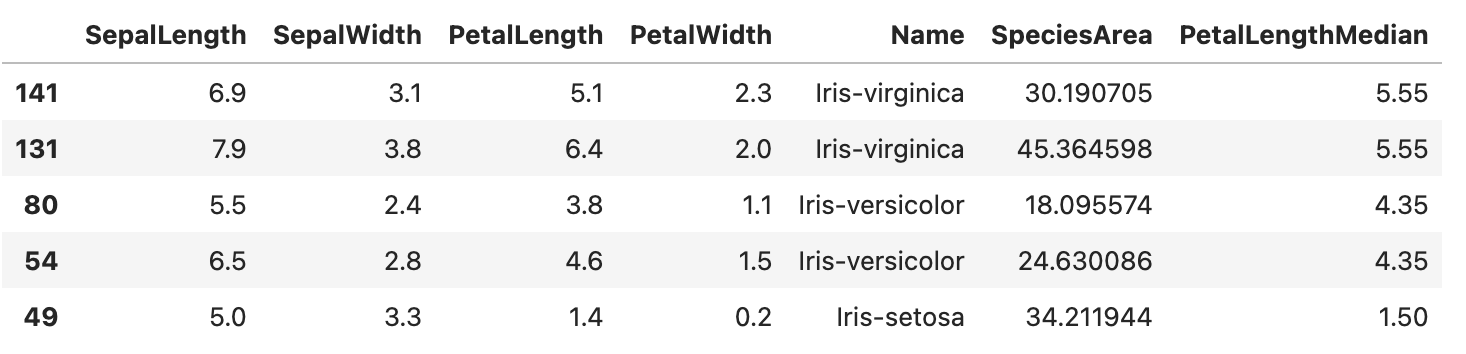

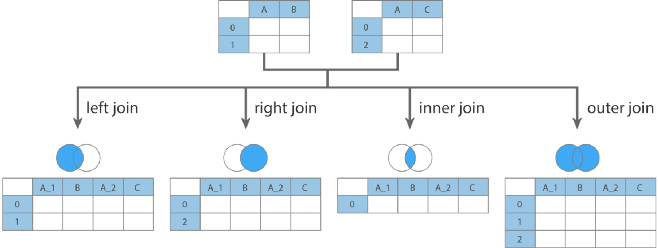

In [25]:
df3=pd.merge(df,df2,how='outer',on=['Name','Name'])
#print(df3)
df3.sample(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,SpeciesArea,PetalLengthMedian
114,5.8,2.8,5.1,2.4,Iris-virginica,24.630086,5.55
29,4.7,3.2,1.6,0.2,Iris-setosa,32.169909,1.50
12,4.8,3.0,1.4,0.1,Iris-setosa,28.274334,1.50
35,5.0,3.2,1.2,0.2,Iris-setosa,32.169909,1.50
98,5.1,2.5,3.0,1.1,Iris-versicolor,19.634954,4.35
66,5.6,3.0,4.5,1.5,Iris-versicolor,28.274334,4.35
108,6.7,2.5,5.8,1.8,Iris-virginica,19.634954,5.55
126,6.2,2.8,4.8,1.8,Iris-virginica,24.630086,5.55
64,5.6,2.9,3.6,1.3,Iris-versicolor,26.420794,4.35
19,5.1,3.8,1.5,0.3,Iris-setosa,45.364598,1.50


## 31. Plot with Pandas DF
Plot with Pandas DF. The default plotting backend of Pandas is Matplotlib. You may plot simple graph with DF without import Matplotlib or other visualisation tools.

<Axes: ylabel='Frequency'>

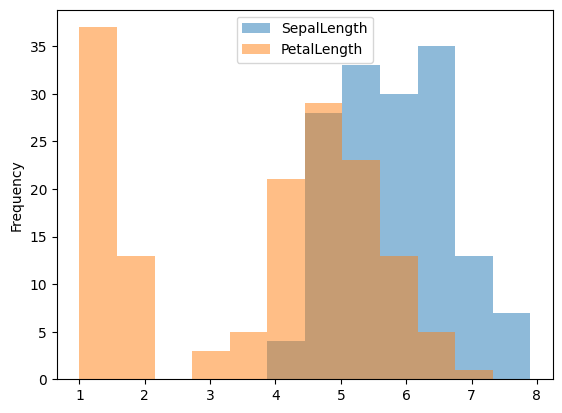

In [26]:
df[['SepalLength','PetalLength']].plot.hist(bins=12, alpha=0.5)

<Axes: ylabel='Frequency'>

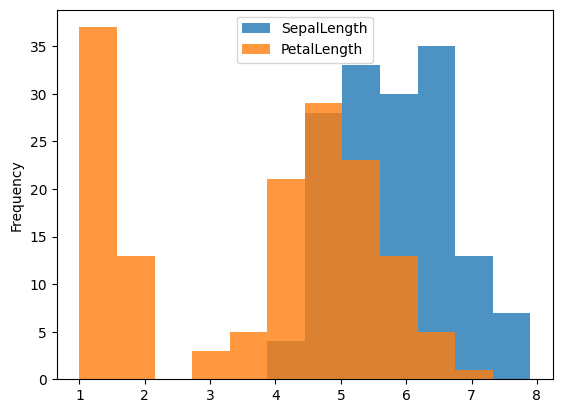

In [27]:
df[['SepalLength','PetalLength']].plot.hist(bins=12,alpha=00.8)

In [28]:
df.plot

<Axes: xlabel='SepalLength', ylabel='SepalWidth'>

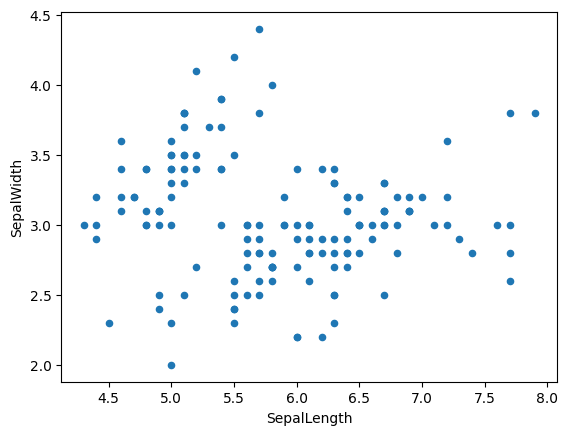

In [29]:
df.plot.scatter(x='SepalLength', y='SepalWidth')

<Axes: ylabel='Density'>

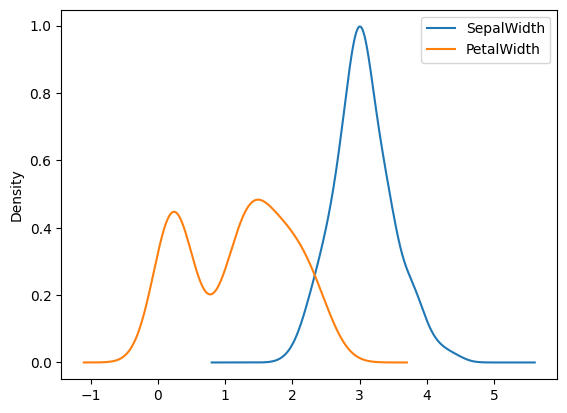

In [30]:
df[['SepalWidth','PetalWidth']].plot.kde()

## 32. Save DataFrame

In [31]:
df.to_html('test.html')


In [32]:
df.to_csv('test.csv')

In [33]:
df.to_markdown('test.md')  

## 33. Pandas dtype
<pre>The default Pandas dtype: 
real number dtype is float64
Int number dtype is int64
String is object</pre>


In [ ]:
df.info()

In [34]:
#df.unique[('Name'),('SepalLength'),('SepalWidth'),('PetalLength'),('PetalWidth')]


df[('PetalWidth')].unique()

array([0.2, 0.4, 0.3, 0.1, 0.5, 0.6, 1.4, 1.5, 1.3, 1.6, 1. , 1.1, 1.8,
       1.2, 1.7, 2.5, 1.9, 2.1, 2.2, 2. , 2.4, 2.3])

In [35]:
df.index

RangeIndex(start=0, stop=150, step=1)

In [36]:
df.columns.values

#df.rows.values

array(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Name',
       'SpeciesArea'], dtype=object)

In [37]:
d = {'col1': [1, 2], 
     'col2': [3., 4.], 
     'col3': ['user1', 'user2']}
df3 = pd.DataFrame(data=d)
df3.dtypes

col1      int64
col2    float64
col3     object
dtype: object

In [38]:
DdD = {
         'col1': np.array([1,2]), 
         'col2': np.array([3.,4.]), 
     'col3': ['user1', 'user2'],

       }
Ddf3D = pd.DataFrame(data=DdD)
print("Ddf3D.dtypes:",'/n',Ddf3D.dtypes)

Ddf3D.dtypes: /n col1      int32
col2    float64
col3     object
dtype: object


In [39]:
type (DdD)

DdD.keys()



dict_keys(['col1', 'col2', 'col3'])

In [40]:
DdD.values()

dict_values([array([1, 2]), array([3., 4.]), ['user1', 'user2']])

In [41]:
DdD.items()

dict_items([('col1', array([1, 2])), ('col2', array([3., 4.])), ('col3', ['user1', 'user2'])])

In [42]:


for key in DdD:
    print(key)

col1
col2
col3


In [43]:
for key , value in DdD.items():
    print(key,value)

col1 [1 2]
col2 [3. 4.]
col3 ['user1', 'user2']


In [44]:
Ddf3D

,col1,col2,col3
0,1,3.0,user1
1,2,4.0,user2


In [ ]:
df3.memory_usage()

In [ ]:
df3.info(verbose = False)

## 34. Check int64 and float64 range

In [45]:

import sys
sys.maxsize

9223372036854775807

In [46]:
type(sys.maxsize)

int

In [47]:
sys.maxsize == 2**63 - 1

True

In [48]:
2**63 - 1

9223372036854775807

## 35. Change numeric column Dtype to float16

In [49]:
# Before trim down the dtype, memory usage: 9.4+ KB
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Columns: 6 entries, SepalLength to SpeciesArea
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


In [50]:
# Trim all numeric column to float16
df[['SepalLength','SepalWidth','PetalLength','PetalWidth','SpeciesArea']] = df[
    ['SepalLength','SepalWidth','PetalLength','PetalWidth','SpeciesArea']].astype(np.float16)

In [51]:
# After trim down the dtype, memory usage: 5.0+ KB
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Columns: 6 entries, SepalLength to SpeciesArea
dtypes: float16(5), object(1)
memory usage: 2.8+ KB


In [ ]:


df.info()

In [52]:
# Max of float16
np.finfo(np.float16).max

65500.0

In [53]:

# Min of float16
np.finfo(np.float16).min

-65500.0

In [54]:
# Max of int64
np.iinfo(np.int64).max

9223372036854775807

In [55]:
# Min of int64
np.iinfo(np.int64).min

-9223372036854775808

In [56]:
# Max of uint64
np.iinfo(np.uint64).max

18446744073709551615

In [57]:
# Min of uint64
np.iinfo(np.uint64).min

0

## 36. Calculates the difference of a DataFrame element compared with another element in the DataFrame 

In [58]:
df[['SepalLength','PetalLength']]

,SepalLength,PetalLength
0,5.101562,1.400391
1,4.898438,1.400391
2,4.699219,1.299805
3,4.601562,1.500000
4,5.000000,1.400391
...,...,...
145,6.699219,5.199219
146,6.300781,5.000000
147,6.500000,5.199219
148,6.199219,5.398438


In [59]:
df[['SepalLength','PetalLength']].diff(axis=1)

,SepalLength,PetalLength
0,NaN,-3.701172
1,NaN,-3.498047
2,NaN,-3.398438
3,NaN,-3.101562
4,NaN,-3.599609
...,...,...
145,NaN,-1.500000
146,NaN,-1.300781
147,NaN,-1.300781
148,NaN,-0.800781


In [60]:
df[['SepalLength','PetalLength']].diff()

,SepalLength,PetalLength
0,NaN,NaN
1,-0.203125,0.000000
2,-0.199219,-0.100586
3,-0.097656,0.200195
4,0.398438,-0.099609
...,...,...
145,0.000000,-0.500000
146,-0.398438,-0.199219
147,0.199219,0.199219
148,-0.300781,0.199219


## 37. Get item from object for given key
<pre>Given a wather DF, use .get() to retrieve windspeed value on '2020-02-13'
weather = pd.DataFrame(
    [   [24.3, 75.7, "high"],
        [31, 87.8, "high"],
        [22, 71.6, "medium"],
        [35, 95, "medium"],
    ],
    columns=["temp_celsius", "temp_fahrenheit", "windspeed"],
    index=pd.date_range(start="2020-02-12", end="2020-02-15", freq="D"),
)</pre>

In [64]:
weather = pd.DataFrame(
    [   [24.3, 75.7, "high"],
        [31, 87.8, "high"],
        [22, 71.6, "medium"],
        [35, 95, "medium"],
    ],
    columns=["temp_celsius", "temp_fahrenheit", "windspeed"],
    index=pd.date_range(start="2020-02-12", end="2020-02-15", freq="D"),
)
weather

,temp_celsius,temp_fahrenheit,windspeed
2020-02-12,24.3,75.7,high
2020-02-13,31.0,87.8,high
2020-02-14,22.0,71.6,medium
2020-02-15,35.0,95.0,medium


In [65]:
weather['windspeed'].get('2020-02-13')

'high'

In [66]:
weather['windspeed'].get('2023-05-20', default="No found")

'No found'

## 38. DataFrame representation

In [67]:
# Return a tuple representing the dimensionality of the DataFrame
print("Shape:",weather.shape,"size", weather.size)
print("ndim:", weather.ndim)

print("Info",weather.info)




Shape: (4, 3) size 12
ndim: 2
Info <bound method DataFrame.info of             temp_celsius  temp_fahrenheit windspeed
2020-02-12          24.3             75.7      high
2020-02-13          31.0             87.8      high
2020-02-14          22.0             71.6    medium
2020-02-15          35.0             95.0    medium>


In [68]:
print("Describe",weather.describe)

Describe <bound method NDFrame.describe of             temp_celsius  temp_fahrenheit windspeed
2020-02-12          24.3             75.7      high
2020-02-13          31.0             87.8      high
2020-02-14          22.0             71.6    medium
2020-02-15          35.0             95.0    medium>


In [69]:
# Return an int representing the number of elements in this object.
#weather.???
print(np.where(weather.size==len(weather.index)*len(weather.columns), 12 , False))
  


12


In [70]:
(np.where(weather.size==len(weather.index)*len(weather.columns), 12 , False))-12
  

0

In [71]:
weather.axes

[DatetimeIndex(['2020-02-12', '2020-02-13', '2020-02-14', '2020-02-15'], dtype='datetime64[ns]', freq='D'),
 Index(['temp_celsius', 'temp_fahrenheit', 'windspeed'], dtype='object')]

In [72]:

# Return an int representing the number of axes / array dimensions
# Return 1 if Series. Otherwise return 2 if DataFrame.
weather.???

SyntaxError: invalid syntax (3346968032.py, line 3)

## 39. DataFrame representation

In [73]:


# Return a list representing the axes of the DataFrame.
weather.axes

[DatetimeIndex(['2020-02-12', '2020-02-13', '2020-02-14', '2020-02-15'], dtype='datetime64[ns]', freq='D'),
 Index(['temp_celsius', 'temp_fahrenheit', 'windspeed'], dtype='object')]

In [ ]:
# Return a Numpy representation of the DataFrame
weather.???

In [ ]:
# The column labels of the DataFrame
weather.???

## 40. Insert new column with values

In [74]:
weather

,temp_celsius,temp_fahrenheit,windspeed
2020-02-12,24.3,75.7,high
2020-02-13,31.0,87.8,high
2020-02-14,22.0,71.6,medium
2020-02-15,35.0,95.0,medium


In [75]:

WWweather=weather

In [76]:
WWweather

,temp_celsius,temp_fahrenheit,windspeed
2020-02-12,24.3,75.7,high
2020-02-13,31.0,87.8,high
2020-02-14,22.0,71.6,medium
2020-02-15,35.0,95.0,medium


In [77]:
WWweather.loc[WWweather.index,'sSunny']=[False, True, False, True]
WWweather



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9220\368355103.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False, True, False, True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  WWweather.loc[WWweather.index,'sSunny']=[False, True, False, True]


,temp_celsius,temp_fahrenheit,windspeed,sSunny
2020-02-12,24.3,75.7,high,False
2020-02-13,31.0,87.8,high,True
2020-02-14,22.0,71.6,medium,False
2020-02-15,35.0,95.0,medium,True


In [78]:
weather.insert(3,'sunny', [False, True, False, True])
weather

,temp_celsius,temp_fahrenheit,windspeed,sunny,sSunny
2020-02-12,24.3,75.7,high,False,False
2020-02-13,31.0,87.8,high,True,True
2020-02-14,22.0,71.6,medium,False,False
2020-02-15,35.0,95.0,medium,True,True


## 41. Insert new data row
<pre>Requirement:
Add '2020-02-16' as datetime index, and row data
[31.0, 87.8, 'medium', True] to DF weather.
</pre>

In [79]:
weather.loc[pd.to_datetime('2020-02-16',format='%Y-%m-%d')] = [31.0, 87.8, 'medium', True]
weather

ValueError: cannot set a row with mismatched columns

## 42. Change Datetime indext to another type

In [ ]:
# change weather.index format to ('%Y-%m-%d 00:00:00')   hint: strftime

In [80]:
weather.index=weather.index.strftime('%Y-%m-%d 00:00:00')

In [81]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 2020-02-12 00:00:00 to 2020-02-15 00:00:00
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temp_celsius     4 non-null      float64
 1   temp_fahrenheit  4 non-null      float64
 2   windspeed        4 non-null      object 
 3   sunny            4 non-null      bool   
 4   sSunny           4 non-null      object 
dtypes: bool(1), float64(2), object(2)
memory usage: 164.0+ bytes


## 43. Time Delta
Represents a duration, the difference between two dates or times

In [82]:
from datetime import datetime, timedelta
today = datetime.now()
str(today)

'2025-05-26 00:29:51.464320'

In [83]:
# 1000 days later, show date and time


In [84]:
# 1000 days later, show date


## 44. PD.date_range
Return a fixed frequency DatetimeIndex.

In [85]:
pd.date_range(start='2023-01-01', periods=8)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08'],
              dtype='datetime64[ns]', freq='D')

In [86]:
pd.date_range(end='2023-01-01', periods=8)

DatetimeIndex(['2022-12-25', '2022-12-26', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30', '2022-12-31', '2023-01-01'],
              dtype='datetime64[ns]', freq='D')

In [87]:
pd.date_range(start='2023-01-01', end='2023-07-01', periods=7)

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-31 04:00:00',
               '2023-03-02 08:00:00', '2023-04-01 12:00:00',
               '2023-05-01 16:00:00', '2023-05-31 20:00:00',
               '2023-07-01 00:00:00'],
              dtype='datetime64[ns]', freq=None)

## 45. Convert Unix time (Epoch time) to datetime

In [88]:
import time
epoch = time.time()
epoch

1748190606.633756

In [89]:
local_time = time.ctime(epoch)
local_time

'Mon May 26 00:30:06 2025'

In [90]:
# Structure time
time.localtime()

time.struct_time(tm_year=2025, tm_mon=5, tm_mday=26, tm_hour=0, tm_min=30, tm_sec=7, tm_wday=0, tm_yday=146, tm_isdst=0)

In [91]:
from datetime import datetime
datetime.fromtimestamp(epoch).strftime( "%d-%m-%Y %H:%M:%S" )

'26-05-2025 00:30:06'